# Home Credit Loan Decision Engine — Model Development

## 0. Environment Setup

Load the libraries and configure the project paths used for data processing, model training, evaluation, and model storage.

In [1]:
import re
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, confusion_matrix
import matplotlib.colors as mcolors
from scipy.stats import randint, uniform
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 100)

DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
(DATA_DIR / "processed").mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True)

## A. Project Overview

This project develops the machine learning component of a loan decision engine using the Home Credit Default Risk dataset.

The application dataset is combined with six related credit-history tables:

- `bureau.csv`
- `bureau_balance.csv`
- `previous_application.csv`
- `POS_CASH_balance.csv`
- `installments_payments.csv`
- `credit_card_balance.csv`

The model estimates each applicant's probability of payment difficulty and assigns the application to one of three operational routes:

- Auto-approve
- Human review
- Auto-decline

The trained model provides the risk score used by the downstream decision pipeline. AI-generated customer communications and response validation are handled separately by the application layer in `src/` and `app/`.

## B. Business Requirements

### B.1 Use Case

Loan applications need to be processed quickly while maintaining appropriate human oversight.

A fully manual process can become a bottleneck as application volume increases. On the other hand, automatically deciding every application can be inappropriate when the model is uncertain.

The decision engine therefore uses risk thresholds to automate high-confidence cases while sending borderline applications to a human underwriter.

For applications that receive an automated decision, the downstream application can generate a customer response and validate the response before delivery.

### B.2 Business Objectives

The system is designed to:

- Reduce the number of applications requiring manual review.
- Identify applicants with higher estimated default risk.
- Route uncertain applications to human underwriters.
- Provide consistent processing for automated decisions.
- Support automated customer communication.
- Add a validation step before AI-generated communications are delivered.
- Maintain an auditable decision pipeline.

### B.3 Operational Requirements

The system should provide:

- A reproducible risk-scoring process.
- Clear routing rules based on model output.
- Human review for uncertain cases.
- Consistent handling of automated decisions.
- Model performance that can be measured using an appropriate classification metric.
- A saved model artifact that can be loaded by the application.

## C. Data Understanding

### C.1 Dataset Overview

The model uses `application_train.csv` together with six related credit-history tables.

This section reviews the available datasets, including:

- Number of records and columns.
- Data types.
- Missing values.
- Key identifiers.
- Target availability.

The goal is to understand the structure and quality of the data before building the modelling dataset.

In [2]:
# show every rows in dataframe
pd.set_option('display.max_rows', None)

In [3]:
RAW_FILES = {
    "application_train": DATA_DIR / "application_train.csv",
    "bureau": DATA_DIR / "bureau.csv",
    "bureau_balance": DATA_DIR / "bureau_balance.csv",
    "previous_application": DATA_DIR / "previous_application.csv",
    "POS_CASH_balance": DATA_DIR / "POS_CASH_balance.csv",
    "installments_payments": DATA_DIR / "installments_payments.csv",
    "credit_card_balance": DATA_DIR / "credit_card_balance.csv",
}

def describe_table(path):
    df = pd.read_csv(path)
    overview = pd.DataFrame({
        "Column": df.columns,
        "Dtype": df.dtypes.astype(str).values,
        "% missing": (df.isna().mean().values * 100).round(1),
    })
    shape = df.shape
    del df
    return overview, shape

for name, path in RAW_FILES.items():
    overview, shape = describe_table(path)
    print(f"{name}.csv  :  {shape[0]:,} rows x {shape[1]} columns")
    display(overview)

application_train.csv  :  307,511 rows x 122 columns


,Column,Dtype,% missing
0,SK_ID_CURR,int64,0.0
1,TARGET,int64,0.0
2,NAME_CONTRACT_TYPE,object,0.0
3,CODE_GENDER,object,0.0
4,FLAG_OWN_CAR,object,0.0
5,FLAG_OWN_REALTY,object,0.0
6,CNT_CHILDREN,int64,0.0
7,AMT_INCOME_TOTAL,float64,0.0
8,AMT_CREDIT,float64,0.0
9,AMT_ANNUITY,float64,0.0


bureau.csv  :  1,716,428 rows x 17 columns


,Column,Dtype,% missing
0,SK_ID_CURR,int64,0.0
1,SK_ID_BUREAU,int64,0.0
2,CREDIT_ACTIVE,object,0.0
3,CREDIT_CURRENCY,object,0.0
4,DAYS_CREDIT,int64,0.0
5,CREDIT_DAY_OVERDUE,int64,0.0
6,DAYS_CREDIT_ENDDATE,float64,6.1
7,DAYS_ENDDATE_FACT,float64,36.9
8,AMT_CREDIT_MAX_OVERDUE,float64,65.5
9,CNT_CREDIT_PROLONG,int64,0.0


bureau_balance.csv  :  27,299,925 rows x 3 columns


...

,Column,Dtype,% missing
0,SK_ID_PREV,int64,0.0
1,SK_ID_CURR,int64,0.0
2,MONTHS_BALANCE,int64,0.0
3,CNT_INSTALMENT,float64,0.3
4,CNT_INSTALMENT_FUTURE,float64,0.3
5,NAME_CONTRACT_STATUS,object,0.0
6,SK_DPD,int64,0.0
7,SK_DPD_DEF,int64,0.0


installments_payments.csv  :  13,605,401 rows x 8 columns


,Column,Dtype,% missing
0,SK_ID_PREV,int64,0.0
1,SK_ID_CURR,int64,0.0
2,NUM_INSTALMENT_VERSION,float64,0.0
3,NUM_INSTALMENT_NUMBER,int64,0.0
4,DAYS_INSTALMENT,float64,0.0
5,DAYS_ENTRY_PAYMENT,float64,0.0
6,AMT_INSTALMENT,float64,0.0
7,AMT_PAYMENT,float64,0.0


credit_card_balance.csv  :  3,840,312 rows x 23 columns


,Column,Dtype,% missing
0,SK_ID_PREV,int64,0.0
1,SK_ID_CURR,int64,0.0
2,MONTHS_BALANCE,int64,0.0
3,AMT_BALANCE,float64,0.0
4,AMT_CREDIT_LIMIT_ACTUAL,int64,0.0
5,AMT_DRAWINGS_ATM_CURRENT,float64,19.5
6,AMT_DRAWINGS_CURRENT,float64,0.0
7,AMT_DRAWINGS_OTHER_CURRENT,float64,19.5
8,AMT_DRAWINGS_POS_CURRENT,float64,19.5
9,AMT_INST_MIN_REGULARITY,float64,7.9


### C.2 Define the Target

The target variable is `TARGET`, provided directly in `application_train.csv`.

- `1` = payment difficulties were recorded.
- `0` = the loan was repaid without recorded payment difficulties.

The model is trained to estimate the likelihood of `TARGET = 1`.

### C.3 Target Availability

`TARGET` is already available in the source dataset, so no additional target construction is required.

In [4]:
app_raw = pd.read_csv(DATA_DIR / "application_train.csv")
print("shape:", app_raw.shape)

target = app_raw["TARGET"]
print("dtype:", target.dtype, "| missing values:", target.isna().sum(), "| unique values:", sorted(target.unique()))

shape: (307511, 122)
dtype: int64 | missing values: 0 | unique values: [np.int64(0), np.int64(1)]


### C.4 Target Distribution

In [5]:
target_dist = target.value_counts(normalize=True).rename({0: "repaid", 1: "payment difficulties"})
display(target_dist.to_frame(name="Proportion"))


,Proportion
TARGET,
repaid,0.919271
payment difficulties,0.080729


In [6]:
print("\nMeaningfully imbalanced: a model that always predicts 'repaid' would score "
      f"{target_dist['repaid']*100:.1f}% accuracy while catching zero defaults. Metric "
      "used throughout this model is ROC-AUC, not accuracy, and class_weight='balanced' "
      "is used on every model.")


Meaningfully imbalanced: a model that always predicts 'repaid' would score 91.9% accuracy while catching zero defaults. Metric used throughout this model is ROC-AUC, not accuracy, and class_weight='balanced' is used on every model.


The target is significantly imbalanced, with the majority of applicants belonging to the non-default class.

Accuracy alone would therefore provide a misleading view of model performance. ROC-AUC is used as the primary model-selection metric because it evaluates how well the model separates higher-risk and lower-risk applicants across classification thresholds.

Class balancing is also applied during model training.

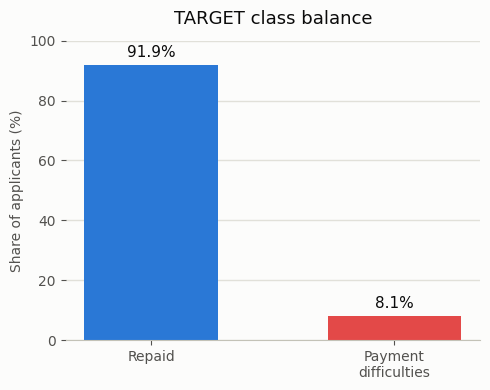

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Repaid", "Payment\ndifficulties"]
values = target_dist.values * 100
bars = ax.bar(labels, values, color=["#2a78d6", "#e34948"], width=0.55)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{v:.1f}%",
            ha="center", va="bottom", color="#0b0b0b", fontsize=11)
ax.set_ylabel("Share of applicants (%)", color="#52514e")
ax.set_title("TARGET class balance", color="#0b0b0b", fontsize=13, pad=12)
ax.set_ylim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
plt.tight_layout()
plt.show()

### C.5 Feature Review — External Credit Sources

Review the external credit-related features to understand their distributions, missing values, and relationship with the target.

These variables are evaluated before feature engineering and model training.

In [8]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_raw[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,-0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,-0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,-0.205478
DAYS_BIRTH,0.078239,-0.600610,-0.091996,-0.205478,1.000000


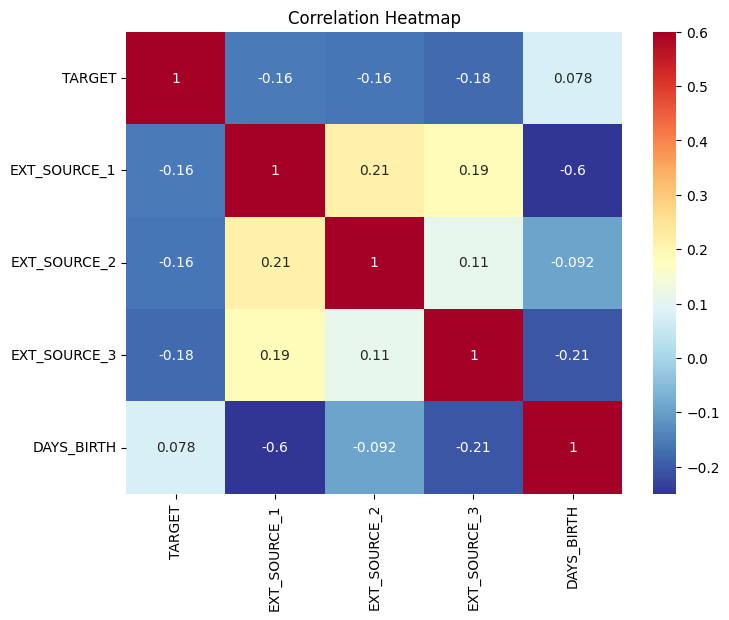

In [9]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap');

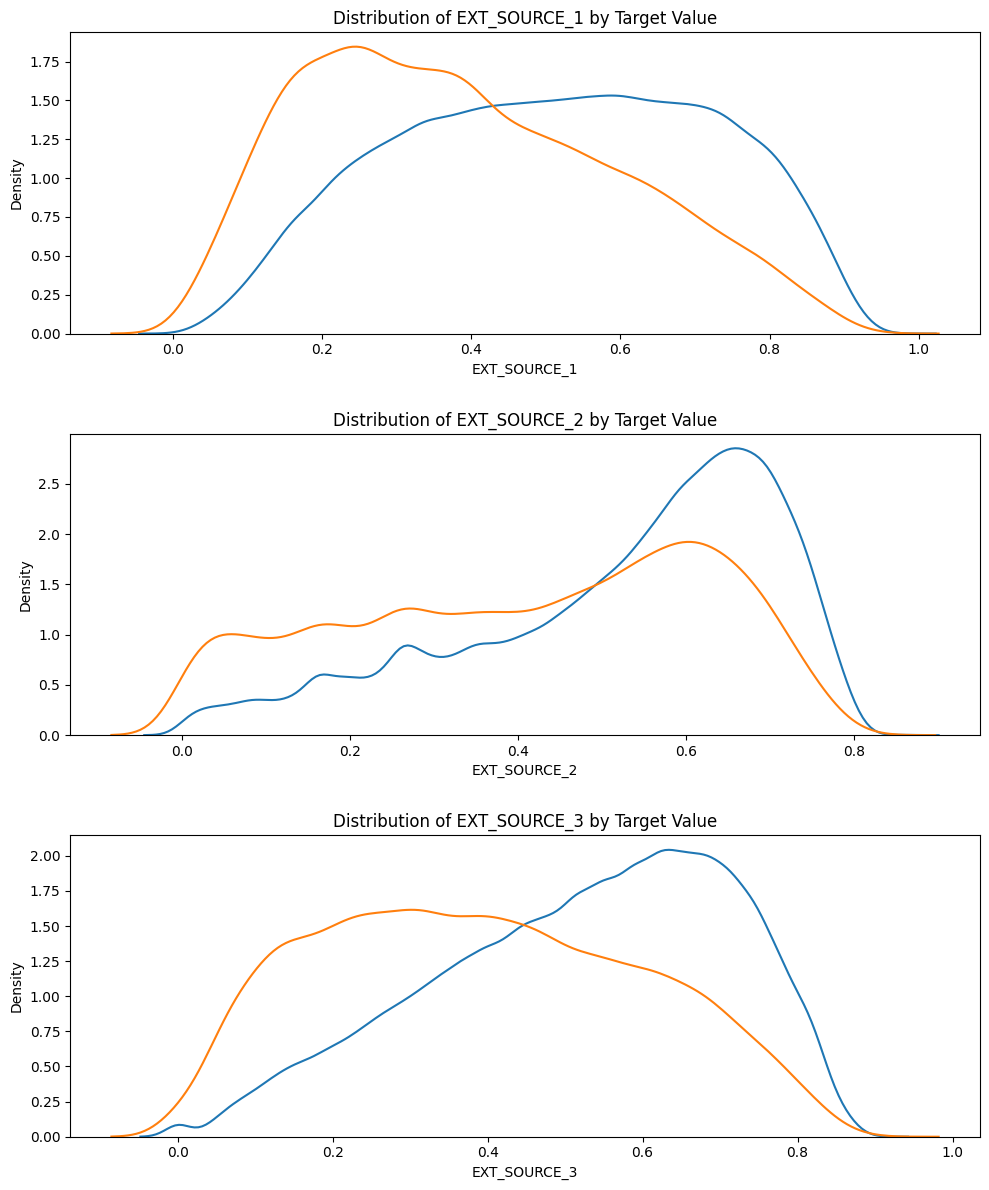

In [10]:
plt.figure(figsize=(10, 12))

for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    plt.subplot(3, 1, i + 1)
    sns.kdeplot(app_raw.loc[app_raw['TARGET'] == 0, source], label='target == 0')
    sns.kdeplot(app_raw.loc[app_raw['TARGET'] == 1, source], label='target == 1')
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source)
    plt.ylabel('Density')

plt.tight_layout(h_pad=2.5)

# Save before show — plt.show() clears the figure from memory in some backends
plt.savefig('ext_source_distributions.png', dpi=300, bbox_inches='tight')

plt.show()

In [11]:
print("columns:", app_raw.shape[1])
print(app_raw.dtypes.value_counts())

missing = app_raw.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"\n{len(missing)} of {app_raw.shape[1]} columns have missing values")
display(missing.head(10).to_frame(name="Fraction missing"))

columns: 122
float64    65
int64      41
object     16
Name: count, dtype: int64

67 of 122 columns have missing values


,Fraction missing
COMMONAREA_MEDI,0.698723
COMMONAREA_AVG,0.698723
COMMONAREA_MODE,0.698723
NONLIVINGAPARTMENTS_MODE,0.694330
NONLIVINGAPARTMENTS_AVG,0.694330
NONLIVINGAPARTMENTS_MEDI,0.694330
FONDKAPREMONT_MODE,0.683862
LIVINGAPARTMENTS_MODE,0.683550
LIVINGAPARTMENTS_AVG,0.683550
LIVINGAPARTMENTS_MEDI,0.683550


In [12]:
# EXT_SOURCE_1/2/3 and DAYS_BIRTH are the known dominant predictors for this dataset --
# confirmed here by direct correlation with TARGET, before any modelling.
ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "DAYS_BIRTH"] if c in app_raw.columns]
corrs = app_raw[ext_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET").sort_values()
display(corrs.to_frame(name="Correlation with TARGET"))

,Correlation with TARGET
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239


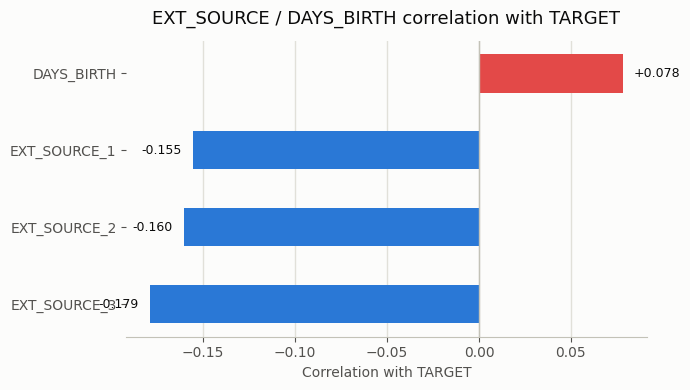

In [13]:
corrs_sorted = corrs.sort_values()
bar_colors = ["#2a78d6" if v < 0 else "#e34948" for v in corrs_sorted.values]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(corrs_sorted.index, corrs_sorted.values, color=bar_colors, height=0.5)
for bar, v in zip(bars, corrs_sorted.values):
    offset = 0.006 if v >= 0 else -0.006
    ha = "left" if v >= 0 else "right"
    ax.text(v + offset, bar.get_y() + bar.get_height() / 2, f"{v:+.3f}",
            va="center", ha=ha, color="#0b0b0b", fontsize=9)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlabel("Correlation with TARGET", color="#52514e")
ax.set_title("EXT_SOURCE / DAYS_BIRTH correlation with TARGET", color="#0b0b0b", fontsize=13, pad=12)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.xaxis.grid(True, color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
plt.tight_layout()
plt.show()

### C.6 Feature Review — Applicant Age

Review `DAYS_BIRTH` to understand the distribution of applicant age and identify values that may require transformation or validation.

In [14]:
(app_raw['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

### C.7 Feature Review — Employment History

Review `DAYS_EMPLOYED` to identify unusual or invalid values before the feature is used for modelling.

In [15]:
app_raw['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

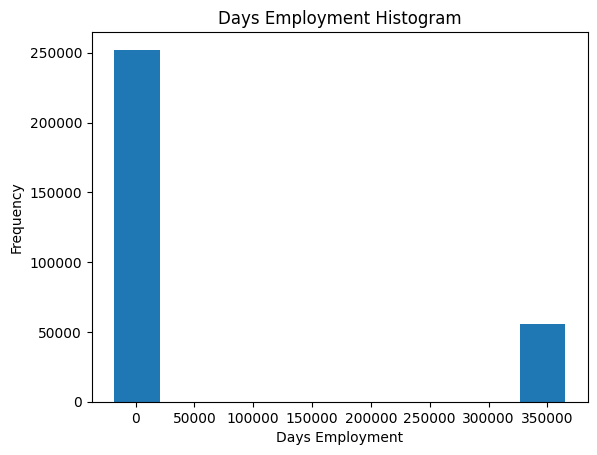

In [16]:
app_raw['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [17]:
anom = app_raw[app_raw['DAYS_EMPLOYED'] == 365243]
non_anom = app_raw[app_raw['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.40% of loans
There are 55374 anomalous days of employment


#### Data Quality Note

Anomalous values in `DAYS_EMPLOYED` are handled during the data-cleaning stage.

In [18]:
bureau_raw = pd.read_csv(DATA_DIR / "bureau.csv")
print("bureau.csv shape:", bureau_raw.shape, "(one-to-many with application_train via SK_ID_CURR)")

in_train = bureau_raw[bureau_raw["SK_ID_CURR"].isin(app_raw["SK_ID_CURR"])]
n_with_bureau = in_train["SK_ID_CURR"].nunique()
print(f"applicants with at least one bureau record: {n_with_bureau} of {app_raw['SK_ID_CURR'].nunique()} "
      f"({n_with_bureau / app_raw['SK_ID_CURR'].nunique() * 100:.1f}%)")
del bureau_raw, in_train

bureau.csv shape: (1716428, 17) (one-to-many with application_train via SK_ID_CURR)
applicants with at least one bureau record: 263491 of 307511 (85.7%)


## D. Data Cleaning & Feature Engineering

### D.1 Build the Modelling Dataset

Combine the application data with the six related credit-history tables.

The tables are aggregated and joined using the appropriate applicant identifiers so that each applicant can be represented by a consolidated set of credit-history features.

Missing-value patterns are reviewed after the datasets are combined.

In [19]:
# CODE_GENDER == 'XNA': negligible (4 rows), drop rather than impute
before = len(app_raw)
app = app_raw[app_raw["CODE_GENDER"] != "XNA"].copy()
print(f"dropped {before - len(app)} XNA-gender rows")

bureau = pd.read_csv(DATA_DIR / "bureau.csv")

bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_ACTIVE_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    BUREAU_CLOSED_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
    BUREAU_CREDIT_TYPE_NUNIQUE=("CREDIT_TYPE", "nunique"),
    BUREAU_DAYS_CREDIT_MEAN=("DAYS_CREDIT", "mean"),
    BUREAU_DAYS_CREDIT_MIN=("DAYS_CREDIT", "min"),
    BUREAU_CREDIT_DAY_OVERDUE_MAX=("CREDIT_DAY_OVERDUE", "max"),
    BUREAU_CREDIT_DAY_OVERDUE_SUM=("CREDIT_DAY_OVERDUE", "sum"),
    BUREAU_CNT_CREDIT_PROLONG_SUM=("CNT_CREDIT_PROLONG", "sum"),
    BUREAU_AMT_CREDIT_SUM_TOTAL=("AMT_CREDIT_SUM", "sum"),
    BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_AMT_CREDIT_SUM_OVERDUE_TOTAL=("AMT_CREDIT_SUM_OVERDUE", "sum"),
).reset_index()
bureau_agg["BUREAU_ACTIVE_RATIO"] = bureau_agg["BUREAU_ACTIVE_COUNT"] / bureau_agg["BUREAU_COUNT"]

# bureau_balance: aggregate to one row per SK_ID_BUREAU, merge onto bureau, re-aggregate to SK_ID_CURR
bb = pd.read_csv(DATA_DIR / "bureau_balance.csv")
bb["IS_DPD"] = bb["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)
bb["DPD_SEVERITY"] = bb["STATUS"].replace({"C": -1, "X": -1, "0": 0}).astype(int)

bb_agg = bb.groupby("SK_ID_BUREAU").agg(
    BB_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    BB_DPD_MONTHS_COUNT=("IS_DPD", "sum"),
    BB_MAX_DPD_SEVERITY=("DPD_SEVERITY", "max"),
).reset_index()
most_recent = (
    bb.sort_values("MONTHS_BALANCE").groupby("SK_ID_BUREAU").tail(1)
    [["SK_ID_BUREAU", "DPD_SEVERITY"]].rename(columns={"DPD_SEVERITY": "BB_MOST_RECENT_STATUS_SEVERITY"})
)
bb_agg = bb_agg.merge(most_recent, on="SK_ID_BUREAU", how="left")
bb_agg["BB_DPD_RATIO"] = bb_agg["BB_DPD_MONTHS_COUNT"] / bb_agg["BB_MONTHS_COUNT"]

bureau_bb = bureau[["SK_ID_CURR", "SK_ID_BUREAU"]].merge(bb_agg, on="SK_ID_BUREAU", how="left")
client_bb_agg = bureau_bb.groupby("SK_ID_CURR").agg(
    BUREAU_BB_MONTHS_MEAN=("BB_MONTHS_COUNT", "mean"),
    BUREAU_BB_MAX_DPD_SEVERITY=("BB_MAX_DPD_SEVERITY", "max"),
    BUREAU_BB_DPD_RATIO_MEAN=("BB_DPD_RATIO", "mean"),
    BUREAU_BB_MOST_RECENT_SEVERITY_MAX=("BB_MOST_RECENT_STATUS_SEVERITY", "max"),
).reset_index()

app = app.merge(bureau_agg, on="SK_ID_CURR", how="left").merge(client_bb_agg, on="SK_ID_CURR", how="left")
app["HAS_BUREAU_HISTORY"] = app["BUREAU_COUNT"].notna().astype(int)
print("after bureau + bureau_balance:", app.shape)

dropped 4 XNA-gender rows


after bureau + bureau_balance: (307507, 140)


In [20]:
# previous_application
prev = pd.read_csv(DATA_DIR / "previous_application.csv")
prev["IS_APPROVED"] = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
prev["IS_REFUSED"] = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
prev["CREDIT_TO_APPLICATION_RATIO"] = prev["AMT_CREDIT"] / prev["AMT_APPLICATION"].replace(0, np.nan)

prev_agg = prev.groupby("SK_ID_CURR").agg(
    PREV_COUNT=("SK_ID_PREV", "count"),
    PREV_APPROVED_RATIO=("IS_APPROVED", "mean"),
    PREV_REFUSED_RATIO=("IS_REFUSED", "mean"),
    PREV_AMT_APPLICATION_MEAN=("AMT_APPLICATION", "mean"),
    PREV_AMT_CREDIT_MEAN=("AMT_CREDIT", "mean"),
    PREV_AMT_ANNUITY_MEAN=("AMT_ANNUITY", "mean"),
    PREV_DAYS_DECISION_MEAN=("DAYS_DECISION", "mean"),
    PREV_DAYS_DECISION_MIN=("DAYS_DECISION", "min"),
    PREV_CNT_PAYMENT_MEAN=("CNT_PAYMENT", "mean"),
    PREV_CREDIT_TO_APPLICATION_RATIO_MEAN=("CREDIT_TO_APPLICATION_RATIO", "mean"),
).reset_index()

# POS_CASH_balance
pos = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
pos["IS_DPD"] = (pos["SK_DPD"] > 0).astype(int)
pos_agg = pos.groupby("SK_ID_CURR").agg(
    POS_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    POS_CONTRACTS_COUNT=("SK_ID_PREV", "nunique"),
    POS_SK_DPD_MAX=("SK_DPD", "max"),
    POS_SK_DPD_MEAN=("SK_DPD", "mean"),
    POS_SK_DPD_DEF_MAX=("SK_DPD_DEF", "max"),
    POS_DPD_MONTHS_RATIO=("IS_DPD", "mean"),
    POS_CNT_INSTALMENT_MEAN=("CNT_INSTALMENT", "mean"),
).reset_index()

# installments_payments
inst = pd.read_csv(DATA_DIR / "installments_payments.csv")
inst["DAYS_LATE"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
inst["IS_LATE"] = (inst["DAYS_LATE"] > 0).astype(int)
inst["PAYMENT_RATIO"] = inst["AMT_PAYMENT"] / inst["AMT_INSTALMENT"].replace(0, np.nan)
inst["IS_UNDERPAID"] = (inst["PAYMENT_RATIO"] < 0.99).astype(int)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_COUNT=("NUM_INSTALMENT_NUMBER", "count"),
    INST_DAYS_LATE_MEAN=("DAYS_LATE", "mean"),
    INST_DAYS_LATE_MAX=("DAYS_LATE", "max"),
    INST_LATE_RATIO=("IS_LATE", "mean"),
    INST_PAYMENT_RATIO_MEAN=("PAYMENT_RATIO", "mean"),
    INST_UNDERPAID_RATIO=("IS_UNDERPAID", "mean"),
    INST_AMT_INSTALMENT_MEAN=("AMT_INSTALMENT", "mean"),
).reset_index()

# credit_card_balance
cc = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
cc["UTILIZATION"] = cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
cc["IS_DPD"] = (cc["SK_DPD"] > 0).astype(int)
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    CC_AMT_BALANCE_MEAN=("AMT_BALANCE", "mean"),
    CC_CREDIT_LIMIT_MEAN=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    CC_UTILIZATION_MEAN=("UTILIZATION", "mean"),
    CC_UTILIZATION_MAX=("UTILIZATION", "max"),
    CC_SK_DPD_MAX=("SK_DPD", "max"),
    CC_DPD_MONTHS_RATIO=("IS_DPD", "mean"),
    CC_AMT_DRAWINGS_CURRENT_MEAN=("AMT_DRAWINGS_CURRENT", "mean"),
    CC_AMT_PAYMENT_TOTAL_MEAN=("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
).reset_index()

app = (
    app.merge(prev_agg, on="SK_ID_CURR", how="left")
       .merge(pos_agg, on="SK_ID_CURR", how="left")
       .merge(inst_agg, on="SK_ID_CURR", how="left")
       .merge(cc_agg, on="SK_ID_CURR", how="left")
)
app["HAS_PREV_APPLICATION"] = app["PREV_COUNT"].notna().astype(int)
app["HAS_POS_CASH"] = app["POS_MONTHS_COUNT"].notna().astype(int)
app["HAS_INSTALMENTS"] = app["INST_COUNT"].notna().astype(int)
app["HAS_CREDIT_CARD"] = app["CC_MONTHS_COUNT"].notna().astype(int)

print("merged (raw, uncleaned):", app.shape)

merged (raw, uncleaned): (307507, 177)


### D.2 Review the Combined Dataset

Review the consolidated dataset before modelling. This includes checking:

- Feature availability.
- Data types.
- Missing-value rates.
- Duplicate or unexpected records.
- Feature distributions.

This provides a final data-quality checkpoint before cleaning and feature preparation.

In [21]:
merged_overview = pd.DataFrame({
    "Column": app.columns,
    "Dtype": app.dtypes.astype(str).values,
    "% missing": (app.isna().mean().values * 100).round(1),
})
print(f"merged dataset:  {app.shape[0]:,} rows x {app.shape[1]} columns")
display(merged_overview)

merged dataset:  307,507 rows x 177 columns


,Column,Dtype,% missing
0,SK_ID_CURR,int64,0.0
1,TARGET,int64,0.0
2,NAME_CONTRACT_TYPE,object,0.0
3,CODE_GENDER,object,0.0
4,FLAG_OWN_CAR,object,0.0
5,FLAG_OWN_REALTY,object,0.0
6,CNT_CHILDREN,int64,0.0
7,AMT_INCOME_TOTAL,float64,0.0
8,AMT_CREDIT,float64,0.0
9,AMT_ANNUITY,float64,0.0


In [22]:
# Number of each type of column
print("Number of each type of column:")
print(app.dtypes.value_counts())

# Number of unique classes in each object (categorical) column
print("\nNumber of unique classes in each object column:")
display(
    app.select_dtypes('object').apply(pd.Series.nunique, axis=0)
    .sort_values(ascending=False)
    .to_frame(name="Unique values")
)

Number of each type of column:
float64    115
int64       46
object      16
Name: count, dtype: int64

Number of unique classes in each object column:


,Unique values
ORGANIZATION_TYPE,58
OCCUPATION_TYPE,18
NAME_INCOME_TYPE,8
NAME_TYPE_SUITE,7
WEEKDAY_APPR_PROCESS_START,7
WALLSMATERIAL_MODE,7
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,4


### D.3 Clean the Modelling Dataset

Apply the required data-quality transformations, including:

1. Correct known sentinel values in `DAYS_EMPLOYED`.
2. Remove features with excessive missing data.
3. Impute remaining missing values using the selected strategy.
4. Ensure the final dataset contains valid model inputs.

The goal is to produce a consistent feature matrix that can be used for both training and inference.

In [23]:
def missing_table(df):
    return (
        df.isnull().sum()
        .to_frame(name='Missing Values')
        .assign(Percentage=lambda x: (x['Missing Values'] / len(df)) * 100)
        .query('`Missing Values` > 0')
        .sort_values('Percentage', ascending=False)
        .reset_index()
        .rename(columns={'index': 'Column'})
    )

# DAYS_EMPLOYED sentinel (365243 = ~1000 years = "no employment record"), ~18% of rows
SENTINEL = 365243
app["DAYS_EMPLOYED_ANOM"] = (app["DAYS_EMPLOYED"] == SENTINEL).astype(int)
app.loc[app["DAYS_EMPLOYED"] == SENTINEL, "DAYS_EMPLOYED"] = np.nan

# drop columns >60% missing -- application_train's own raw columns only, not the
# merged aggregate columns (see the note above) to keep 
raw_app_cols = [c for c in app_raw.columns if c not in ("SK_ID_CURR", "TARGET")]
null_table = missing_table(app[raw_app_cols])
cols_to_drop = null_table.loc[null_table['Percentage'] > 60, 'Column'].tolist()
print(f"dropping {len(cols_to_drop)} raw application-level columns >60% missing")
app = app.drop(columns=cols_to_drop)

# impute the rest: median + missing-flag for numeric, 'Missing' category for categorical
remaining = missing_table(app)
for col in remaining['Column']:
    if app[col].dtype in ("float64", "int64"):
        app[f"{col}_WAS_MISSING"] = app[col].isna().astype(int)
        app[col] = app[col].fillna(app[col].median())
    else:
        app[col] = app[col].fillna("Missing")

print("cleaned:", app.shape, "| missing values remaining:", app.isna().sum().sum())

dropping 17 raw application-level columns >60% missing


/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_72910/4085840860.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app[f"{col}_WAS_MISSING"] = app[col].isna().astype(int)
/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_72910/4085840860.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app[f"{col}_WAS_MISSING"] = app[col].isna().astype(int)
/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_72910/4085840860.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result o

cleaned: (307507, 257) | missing values remaining: 0


In [24]:
# check DAYS_EMPLOYED_ANOM
app["DAYS_EMPLOYED_ANOM"]

0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         1
9         0
10        0
11        1
12        0
13        0
14        0
15        0
16        0
17        0
18        0
19        0
20        0
21        0
22        0
23        1
24        0
25        0
26        0
27        0
28        0
29        0
30        0
31        0
32        0
33        0
34        0
35        0
36        0
37        0
38        1
39        0
40        0
41        0
42        0
43        1
44        0
45        0
46        1
47        0
48        0
49        0
50        0
51        0
52        0
53        0
54        1
55        0
56        1
57        0
58        0
59        0
60        0
61        0
62        1
63        0
64        0
65        0
66        0
67        0
68        0
69        0
70        0
71        0
72        0
73        0
74        0
75        0
76        0
77        0
78        0
79        1
80        0
81        1
82        0
83  

### D.4 Credit Risk Features

Create additional features based on credit and affordability relationships. The engineered features include:

- Credit-to-income ratio
- Annuity-to-income ratio
- Implied loan term
- Employment-to-age ratio

These features provide the model with additional information about an applicant's borrowing level, repayment burden, loan structure, and employment history.

In [25]:
app['CREDIT_INCOME_PERCENT'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL'].replace(0, np.nan)
app['ANNUITY_INCOME_PERCENT'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL'].replace(0, np.nan)
app['CREDIT_TERM'] = app['AMT_ANNUITY'] / app['AMT_CREDIT'].replace(0, np.nan)
app['DAYS_EMPLOYED_PERCENT'] = app['DAYS_EMPLOYED'] / app['DAYS_BIRTH'].replace(0, np.nan)

domain_features = ['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']
display(app[domain_features].describe())

# save here, not at the end of D.3 -- this is the last step that mutates `app` before
# feature selection, so this is the point at which "the full cleaned schema" is actually
# complete. src/features.py reads this file for its imputation medians, so if a column
# exists in app but not here, live scoring for a new applicant breaks on it.
app.to_csv(DATA_DIR / "processed" / "application_train_full_schema.csv", index=False)

/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_72910/3733542773.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['CREDIT_INCOME_PERCENT'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL'].replace(0, np.nan)
/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_72910/3733542773.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['ANNUITY_INCOME_PERCENT'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL'].replace(0, np.nan)
/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_72910/3733542773.py:3: Perfor

,CREDIT_INCOME_PERCENT,ANNUITY_INCOME_PERCENT,CREDIT_TERM,DAYS_EMPLOYED_PERCENT
count,307507.000000,307507.000000,307507.000000,307507.000000
mean,3.957593,0.180930,0.053695,0.142370
std,2.689737,0.094573,0.022482,0.124882
min,0.004808,0.000224,0.016790,-0.000000
25%,2.018667,0.114785,0.036900,0.066851
50%,3.265067,0.162833,0.050000,0.091035
75%,5.159909,0.229067,0.064044,0.191050
max,84.736842,1.875965,0.158114,0.728811


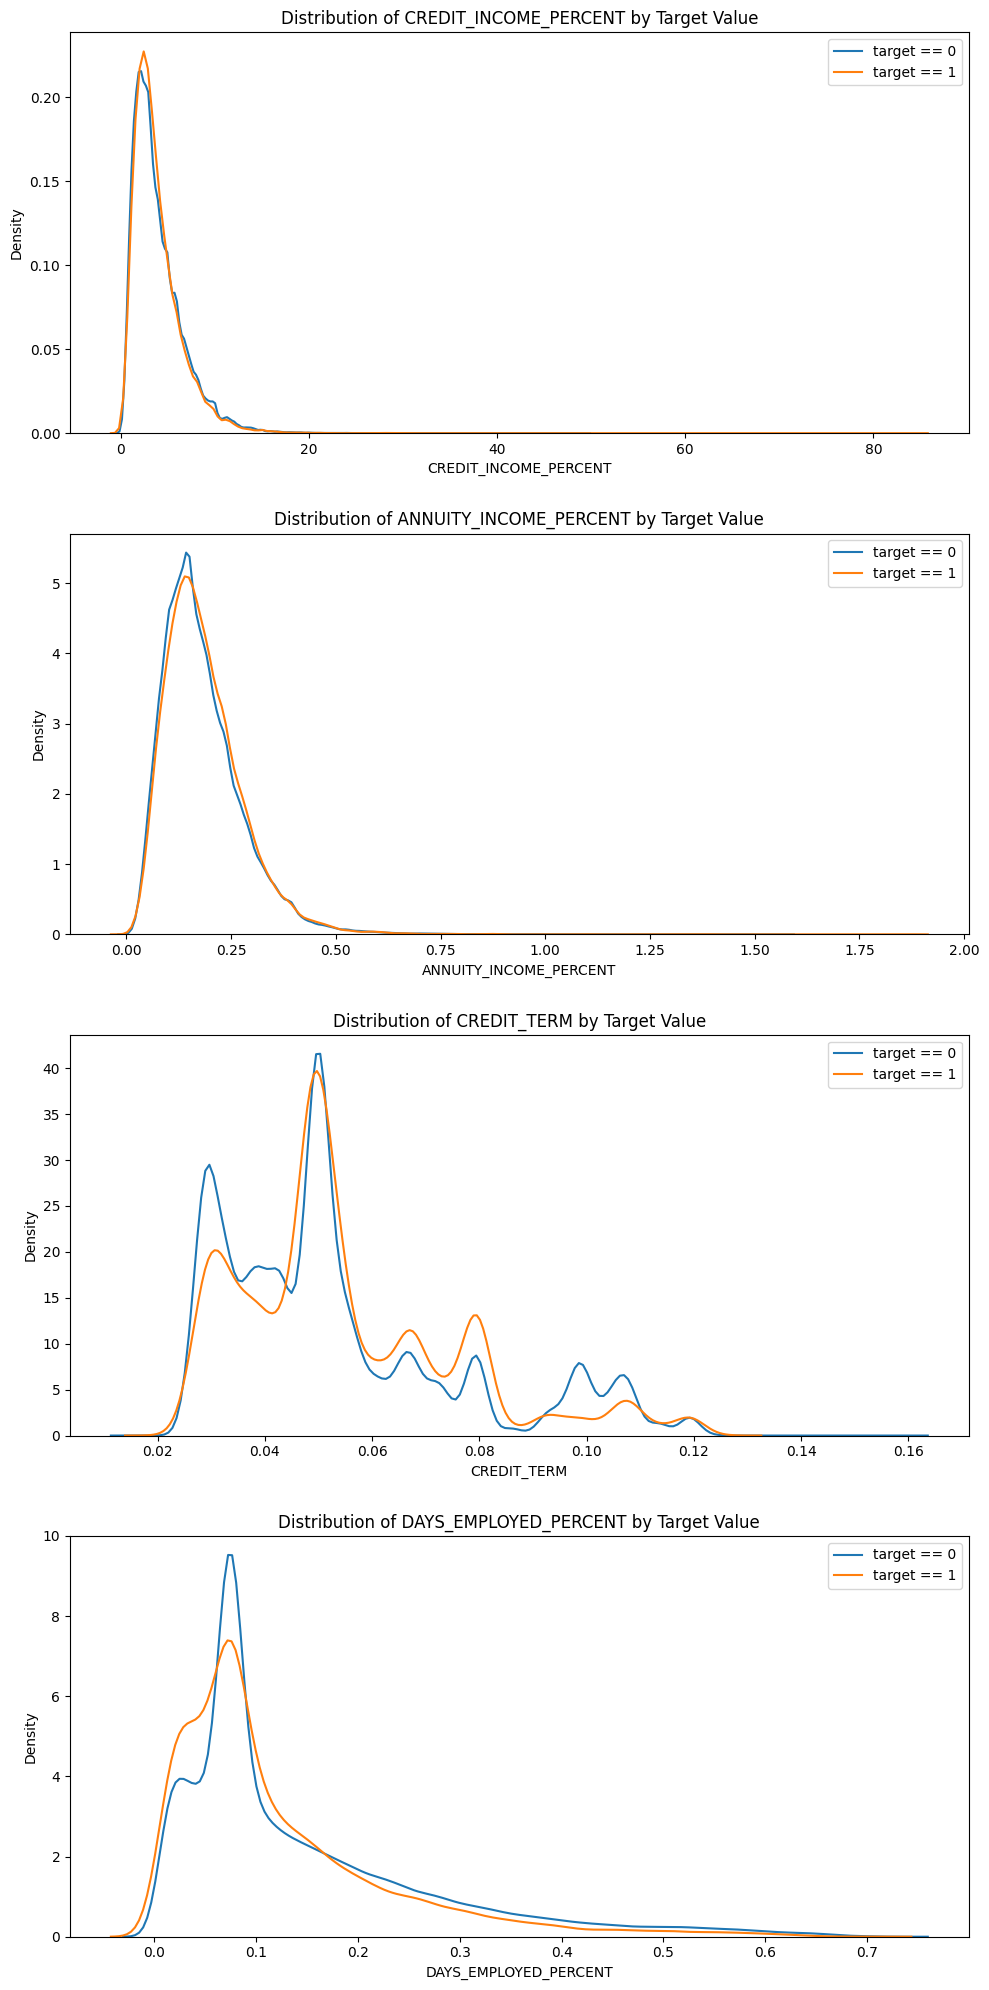

In [26]:
plt.figure(figsize=(10, 20))

# iterate through the new features
for i, feature in enumerate(domain_features):
    # create a new subplot for each feature
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app.loc[app['TARGET'] == 0, feature], label='target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app.loc[app['TARGET'] == 1, feature], label='target == 1')

    # label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density')
    plt.legend()

plt.tight_layout(h_pad=2.5)
plt.show()

## E. Feature Encoding

Convert categorical variables into numerical features using one-hot encoding.

Encoding is performed before feature selection so that the feature-selection process evaluates the individual categories that will actually be provided to the model.

The resulting feature matrix contains only numerical inputs suitable for machine learning.

In [27]:
cat_cols_all = app.select_dtypes(include="object").columns.tolist()
df_encoded_full = pd.get_dummies(app, columns=cat_cols_all, drop_first=True)
df_encoded_full.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", c) for c in df_encoded_full.columns]
print("encoded (every column, before selection):", df_encoded_full.shape)

encoded (every column, before selection): (307507, 371)


## F. Feature Selection

Reduce the feature set using multiple screening methods:

- Low-variance feature removal.
- Correlation analysis.
- Random Forest feature importance.

The objective is to remove redundant or low-information features while retaining variables that contribute useful predictive information.

The selected features form the final input set for model training.

In [28]:
id_cols = ["SK_ID_CURR", "TARGET"]
feature_cols = [c for c in df_encoded_full.columns if c not in id_cols]
dummy_cols = df_encoded_full[feature_cols].select_dtypes(include="bool").columns.tolist()
numeric_cols = [c for c in feature_cols if c not in dummy_cols]

variance = df_encoded_full[numeric_cols].var().sort_values()
near_zero_var = variance[variance < 1e-4]
numeric_cols = [c for c in numeric_cols if c not in near_zero_var.index]
print(f"dropped {len(near_zero_var)} near-zero-variance numeric columns (one-hot columns skipped -- see note above)")

candidate_cols = numeric_cols + dummy_cols
corr = df_encoded_full[candidate_cols].astype(float).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant_pairs = (
    upper.stack().reset_index().rename(columns={"level_0": "A", "level_1": "B", 0: "Correlation"})
    .query("Correlation > 0.9")
)
to_drop = set()
for _, row in redundant_pairs.iterrows():
    a, b = row["A"], row["B"]
    if a in to_drop or b in to_drop:
        continue
    if a.endswith(("_AVG", "_MEAN")):
        to_drop.add(b)
    elif b.endswith(("_AVG", "_MEAN")):
        to_drop.add(a)
    else:
        to_drop.add(b)
candidate_cols = [c for c in candidate_cols if c not in to_drop]
print(f"dropped {len(to_drop)} redundant (|corr|>0.9) columns -- {len(candidate_cols)} candidates remain")

rf = RandomForestClassifier(n_estimators=150, max_depth=10, n_jobs=-1, random_state=42, class_weight="balanced")
rf.fit(df_encoded_full[candidate_cols], df_encoded_full["TARGET"])
importance = pd.Series(rf.feature_importances_, index=candidate_cols).sort_values(ascending=False)
cumulative = importance.cumsum()
selected_features = importance.index[: (cumulative <= 0.95).sum() + 1].tolist()
print(f"{len(selected_features)} of {len(candidate_cols)} encoded features selected (95% cumulative importance)")

# raw (pre-encoding) feature list, for anything downstream that needs real category
# labels rather than dummy columns -- a categorical variable is "selected" here if any
# one of its one-hot columns survived above.
raw_selected_features = [c for c in numeric_cols if c in selected_features]
for cat_col in cat_cols_all:
    if any(sel.startswith(f"{cat_col}_") for sel in selected_features):
        raw_selected_features.append(cat_col)
print(f"({len(raw_selected_features)} raw fields represented, for the readable export / live scoring)")

with open(DATA_DIR / "processed" / "selected_features_full.txt", "w") as f:
    f.write("\n".join(raw_selected_features))

selected_df = app[["SK_ID_CURR", "TARGET"] + raw_selected_features]
selected_df.to_csv(DATA_DIR / "processed" / "application_selected_features_full.csv", index=False)

df_encoded = df_encoded_full[["SK_ID_CURR", "TARGET"] + selected_features]
df_encoded.to_csv(DATA_DIR / "processed" / "application_train_model_ready_full.csv", index=False)
print("model-ready (encoded, selected):", df_encoded.shape)

dropped 8 near-zero-variance numeric columns (one-hot columns skipped -- see note above)


dropped 117 redundant (|corr|>0.9) columns -- 244 candidates remain


74 of 244 encoded features selected (95% cumulative importance)
(73 raw fields represented, for the readable export / live scoring)


model-ready (encoded, selected): (307507, 76)


## G. Model Data Preparation

Prepare the final feature matrix and target variable for model development.

### G.1 Train/Test Split

Split the dataset into training and test sets using a stratified split.

The training set is used for model development and hyperparameter tuning, while the test set is reserved for evaluating performance on unseen data.

In [29]:
X = df_encoded.drop(columns=["SK_ID_CURR", "TARGET"])
y = df_encoded["TARGET"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"train: {X_train.shape}, validation: {X_val.shape}")

train: (246005, 74), validation: (61502, 74)


## H. Model Training

### H.0 Baseline Model

Establish a baseline before evaluating more complex models.

The baseline provides a reference point for determining whether the machine learning models provide meaningful predictive improvement.

In [30]:
base_model = lgb.LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
base_model.fit(X_train, y_train)
base_auc = roc_auc_score(y_val, base_model.predict_proba(X_val)[:, 1])
print(f"base LightGBM (default params) ROC-AUC: {base_auc:.4f}")

base LightGBM (default params) ROC-AUC: 0.7772


### H.1 Algorithm Comparison

Evaluate multiple classification algorithms using the same prepared dataset and evaluation framework:

- LightGBM
- XGBoost
- Random Forest
- Logistic Regression

ROC-AUC is used as the primary comparison metric.

In [31]:
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, n_jobs=-1, eval_metric="auc",
)
xgb_base.fit(X_train, y_train)

rf_base = RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42)
rf_base.fit(X_train, y_train)

scaler_base = StandardScaler()
X_train_scaled_base = scaler_base.fit_transform(X_train)
X_val_scaled_base = scaler_base.transform(X_val)
lr_base = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_base.fit(X_train_scaled_base, y_train)

before_tuning = pd.DataFrame({
    "Model": ["LightGBM (base)", "XGBoost (default)", "RandomForest (default)", "Logistic Regression (default)"],
    "ROC-AUC": [
        base_auc,
        roc_auc_score(y_val, xgb_base.predict_proba(X_val)[:, 1]),
        roc_auc_score(y_val, rf_base.predict_proba(X_val)[:, 1]),
        roc_auc_score(y_val, lr_base.predict_proba(X_val_scaled_base)[:, 1]),
    ],
})
display(before_tuning.sort_values("ROC-AUC", ascending=False))

,Model,ROC-AUC
0,LightGBM (base),0.777214
3,Logistic Regression (default),0.761478
1,XGBoost (default),0.761335
2,RandomForest (default),0.743779


### H.2 Hyperparameter Tuning & Model Fitting

Tune the LightGBM model using `RandomizedSearchCV`.

The search evaluates 40 candidate parameter combinations using 3-fold cross-validation and ROC-AUC as the scoring metric.

The best-performing configuration is then fitted to the training data.

In [32]:
param_dist = {
    "num_leaves": randint(15, 127),
    "max_depth": randint(3, 12),
    "learning_rate": uniform(0.01, 0.19),
    "n_estimators": randint(100, 500),
    "min_child_samples": randint(10, 100),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0, 1),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    lgb.LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist, n_iter=40, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=42, verbose=1,
)
search.fit(X_train, y_train)

Fitting 3 folds for each of 40 candidates, totalling 120 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(class_weight='balanced', n_jobs=-1,
                                            random_state=42, verbose=-1),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x15ea04c10>,
                                        'learning_rate': <scipy.stats._distn_infrastructu...
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x15d488a10>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x14757aa90>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x15d0c5750>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x1759bd810>},
                   random_state=42, scoring='roc_auc', verbose=1)

### H.3 Model Performance

Evaluate the tuned LightGBM model on the held-out test set.

Performance is assessed using classification metrics and diagnostic plots to understand both overall discrimination and classification behaviour.

#### H.3.1 Selected Hyperparameters

Display the hyperparameter configuration selected during cross-validation.

These parameters define the LightGBM model used in the final pipeline.

In [33]:
tuned_model = search.best_estimator_
tuned_auc = roc_auc_score(y_val, tuned_model.predict_proba(X_val)[:, 1])
print(f"tuned LightGBM ROC-AUC: {tuned_auc:.4f} (base was {base_auc:.4f})")
print("best params:", search.best_params_)

joblib.dump(tuned_model, MODELS_DIR / "lightgbm_full_schema_tuned.joblib")
print(classification_report(y_val, tuned_model.predict(X_val), target_names=["repaid", "default"]))

tuned LightGBM ROC-AUC: 0.7798 (base was 0.7772)
best params: {'colsample_bytree': np.float64(0.7700623497964979), 'learning_rate': np.float64(0.04950891594495588), 'max_depth': 6, 'min_child_samples': 63, 'n_estimators': 290, 'num_leaves': 32, 'reg_alpha': np.float64(0.7751328233611146), 'reg_lambda': np.float64(0.9394989415641891), 'subsample': np.float64(0.9579309401710595)}


              precision    recall  f1-score   support

      repaid       0.96      0.73      0.83     56537
     default       0.18      0.69      0.29      4965

    accuracy                           0.73     61502
   macro avg       0.57      0.71      0.56     61502
weighted avg       0.90      0.73      0.79     61502



#### H.3.2 ROC Curve & Confusion Matrix

Use the ROC curve to evaluate the model's ability to distinguish between applicants with and without payment difficulties.

Use the confusion matrix to examine the number of correct and incorrect predictions at the selected classification threshold.

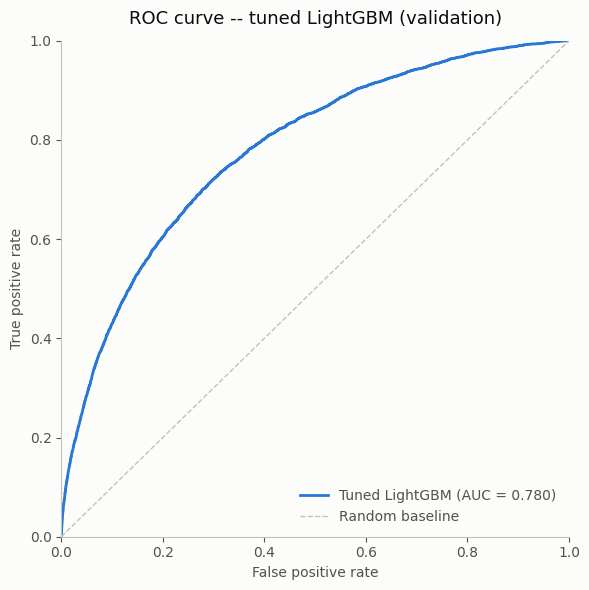

In [34]:
fpr, tpr, _ = roc_curve(y_val, tuned_model.predict_proba(X_val)[:, 1])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#2a78d6", linewidth=2, label=f"Tuned LightGBM (AUC = {tuned_auc:.3f})")
ax.plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1, linestyle="--", label="Random baseline")
ax.set_xlabel("False positive rate", color="#52514e")
ax.set_ylabel("True positive rate", color="#52514e")
ax.set_title("ROC curve -- tuned LightGBM (validation)", color="#0b0b0b", fontsize=13, pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.legend(frameon=False, labelcolor="#52514e", loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
plt.tight_layout()
plt.show()

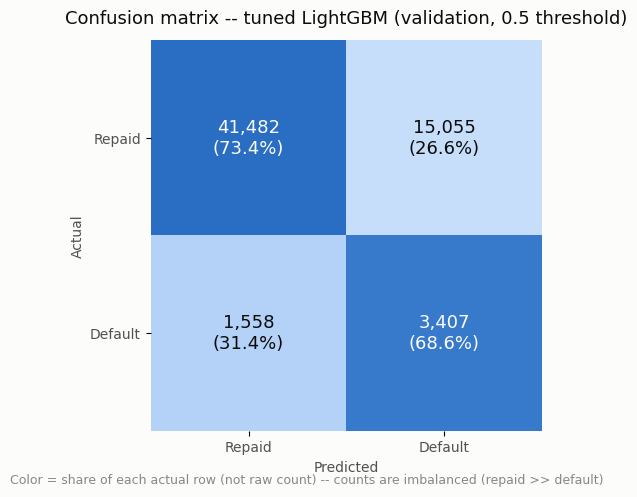

In [35]:
blue_ramp = mcolors.LinearSegmentedColormap.from_list(
    "seq_blue", ["#fcfcfb", "#cde2fb", "#6da7ec", "#256abf", "#0d366b"]
)

cm = confusion_matrix(y_val, tuned_model.predict(X_val))
cm_row_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels = ["Repaid", "Default"]

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm_row_pct, cmap=blue_ramp, vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        text_color = "#fcfcfb" if cm_row_pct[i, j] > 0.5 else "#0b0b0b"
        ax.text(j, i, f"{cm[i, j]:,}\n({cm_row_pct[i, j]*100:.1f}%)",
                ha="center", va="center", color=text_color, fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, color="#52514e")
ax.set_yticks([0, 1]); ax.set_yticklabels(labels, color="#52514e")
ax.set_xlabel("Predicted", color="#52514e")
ax.set_ylabel("Actual", color="#52514e")
ax.set_title("Confusion matrix -- tuned LightGBM (validation, 0.5 threshold)", color="#0b0b0b", fontsize=13, pad=12)
fig.text(0.5, 0.01, "Color = share of each actual row (not raw count) -- counts are imbalanced (repaid >> default)",
         ha="center", va="bottom", color="#898781", fontsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
plt.tight_layout()
plt.show()

## I. Model Comparison

Compare the final LightGBM model against the other candidate models:

- LightGBM
- XGBoost
- Random Forest
- Logistic Regression

A simple model blend is also evaluated as an additional reference. The blend uses the average prediction from the four models. It is a simple averaging approach rather than a full stacking architecture with an out-of-fold meta-model.

The comparison is used to select the model configuration for the downstream decision pipeline.

In [36]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, n_jobs=-1, eval_metric="auc",
)
xgb_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
lr_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lgb_proba = tuned_model.predict_proba(X_val)[:, 1]
xgb_proba = xgb_model.predict_proba(X_val)[:, 1]
rf_proba = rf_model.predict_proba(X_val)[:, 1]
lr_proba = lr_model.predict_proba(X_val_scaled)[:, 1]

blend_auc = roc_auc_score(y_val, (lgb_proba + xgb_proba + rf_proba + lr_proba) / 4)

results = pd.DataFrame({
    "Model": ["LightGBM (tuned)", "XGBoost", "RandomForest", "Logistic Regression", "Blend (simple avg)"],
    "ROC-AUC": [
        roc_auc_score(y_val, lgb_proba), roc_auc_score(y_val, xgb_proba),
        roc_auc_score(y_val, rf_proba), roc_auc_score(y_val, lr_proba), blend_auc,
    ],
})
display(results.sort_values("ROC-AUC", ascending=False))


,Model,ROC-AUC
0,LightGBM (tuned),0.779830
1,XGBoost,0.777709
4,Blend (simple avg),0.776908
3,Logistic Regression,0.761478
2,RandomForest,0.758676


## J. Final Model & Deployment Artifact

The tuned LightGBM model is selected as the final model for the loan decision pipeline.

It is trained using the prepared six-table feature schema and saved as a model artifact for use by the application.

The application loads this artifact during inference to generate a risk score for each submitted application.

The model output is then passed to the decision-routing layer, where business rules determine whether the application is automatically approved, automatically declined, or sent for human review.